前五行数据：
   Id MSZoning  LotArea LotShape  OverallCond  YearBuilt RoofStyle Foundation  \
0   1       RL     8450      Reg            5       2003     Gable      PConc   
1   2       RL     9600      Reg            8       1976     Gable     CBlock   
2   3       RL    11250      IR1            5       2001     Gable      PConc   
3   4       RL     9550      IR1            5       1915     Gable     BrkTil   
4   5       RL    14260      IR1            5       2000     Gable      PConc   

   TotalBsmtSF Heating Electrical  GrLivArea KitchenQual  TotRmsAbvGrd  \
0        856.0    GasA      SBrkr       1710          Gd             8   
1       1262.0    GasA      SBrkr       1262          TA             6   
2        920.0    GasA      SBrkr       1786          Gd             6   
3        756.0    GasA      SBrkr       1717          Gd             7   
4       1145.0    GasA      SBrkr       2198          Gd             9   

  GarageType  GarageYrBlt  GarageArea GarageCond  YrSold  Sal

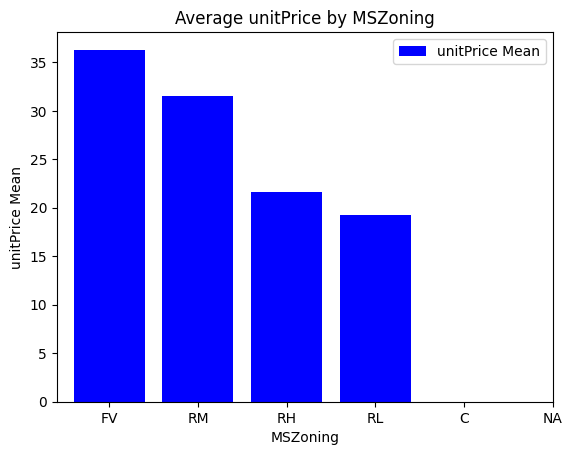

/tmp/ipykernel_234243/1144592281.py:36: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.savefig('house_year_unit_price.png', dpi=300)
/tmp/ipykernel_234243/1144592281.py:36: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.savefig('house_year_unit_price.png', dpi=300)
/tmp/ipykernel_234243/1144592281.py:36: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.savefig('house_year_unit_price.png', dpi=300)
/tmp/ipykernel_234243/1144592281.py:36: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  plt.savefig('house_year_unit_price.png', dpi=300)
/tmp/ipykernel_234243/1144592281.py:36: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.savefig('house_year_unit_price.png', dpi=300)
/home/bz/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: Use

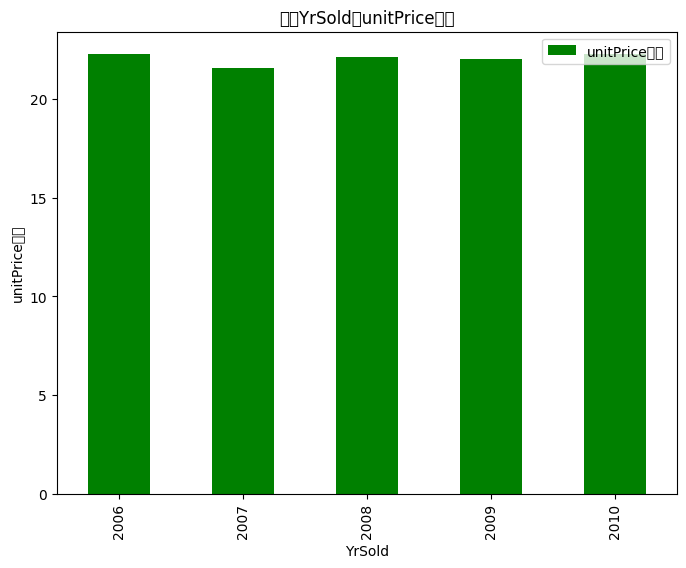

In [2]:
import pandas as pd
df=pd.read_csv('31.house.sale.price.csv')
print("前五行数据：")
print(df.head(5))
print("后两行数据:")
print(df.tail(2))
selected_df=df[['Id', 'MSZoning' ,'LotArea' ,'YrSold' ,'SalePrice']]
df_cleaned=selected_df.dropna()
df_cleaned.to_csv('house_total_price.txt',index=False)
new_df = pd.read_csv('house_total_price.txt', sep=',')
new_df['unitPrice'] = new_df['SalePrice'] / new_df['LotArea']
new_df.to_excel('house_unit_price.xlsx', index=False)
import matplotlib.pyplot as plt
df = pd.read_excel('house_unit_price.xlsx')
grouped_mean = df.groupby('MSZoning')['unitPrice'].mean().reset_index()
sorted_grouped_mean = grouped_mean.sort_values(by='unitPrice', ascending=False)
x_ticks = ['C', 'FV', 'NA', 'RH', 'RL', 'RM']
sorted_grouped_mean = sorted_grouped_mean[sorted_grouped_mean['MSZoning'].isin(x_ticks)]
plt.bar(sorted_grouped_mean['MSZoning'], sorted_grouped_mean['unitPrice'], color='blue')
plt.xlabel('MSZoning')
plt.ylabel('unitPrice Mean')
plt.title('Average unitPrice by MSZoning')
plt.xticks(x_ticks)
plt.legend(['unitPrice Mean'])
plt.savefig('house_unit_price.png', dpi=300)
plt.show()
df_from_excel = pd.read_excel('house_unit_price.xlsx')
grouped = df_from_excel.groupby('YrSold')['unitPrice'].mean()
ax = grouped.plot(kind='bar', color='green', label='unitPrice均值', figsize=(8, 6))
ax.set_xlabel('YrSold')
ax.set_ylabel('unitPrice均值')
ax.set_title('不同YrSold的unitPrice均值')
ax.set_xticks(range(len(grouped.index)))
ax.set_xticklabels(grouped.index)
plt.legend()
plt.savefig('house_year_unit_price.png', dpi=300)
plt.show()